In [2]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Read in tornado and teleconnection datasets
tornadoes = pd.read_csv('https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv')

enso = pd.read_csv('https://www.atmos.illinois.edu/~snesbitt/soi.dat',sep=r'\s+', 
                   header=None, skiprows=4, skipfooter=0, engine='python')
nao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',
                  sep=r'\s+', header=None, skiprows=1, engine='python')
ao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',
                  sep=r'\s+', header=None, skiprows=1, engine='python')

In [ ]:
# For some reason, the url for this data was timing out, so I just had to download it
#pdo = pd.read_csv('https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',
#                  sep=r'\s+', header=None, skiprows=2, engine='python')
pdo = pd.read_csv('./ersst.v5.pdo.dat',
                  sep=r'\s+', header=None, skiprows=2, engine='python')

# Part 1: Aggregate tornado data

In [11]:
# Select all Illinois tornadoes
il_tornadoes = tornadoes.loc[tornadoes['st']=='IL']

# Convert dates to datetime objects
il_tornadoes['date'] = pd.to_datetime(il_tornadoes['date'])
il_tornadoes.set_index('date', inplace=True)

# Use pd.Grouper to group counts by individual months
il_torn_count = il_tornadoes.groupby(pd.Grouper(freq='ME')).size()

# Set datetimes to be the first of each month instead of last
il_torn_count = il_torn_count.to_period("M").to_timestamp()

il_torn_count

/tmp/ipykernel_1302725/2602888489.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  il_tornadoes['date'] = pd.to_datetime(il_tornadoes['date'])


date
1950-01-01     2
1950-02-01     0
1950-03-01     1
1950-04-01     0
1950-05-01     0
              ..
2021-08-01    16
2021-09-01     0
2021-10-01    10
2021-11-01     0
2021-12-01     8
Freq: MS, Length: 864, dtype: int64

# Part 2

In [ ]:
# First need to recreate teleconnections dataframe from module 4 notebook 1

enso_new=pd.DataFrame()
nao_new=pd.DataFrame()
pdo_new=pd.DataFrame()
ao_new=pd.DataFrame()

# Create monthly date intervals
enso_new['Date'] = pd.date_range(start=datetime.datetime(enso[0].iloc[0],1,1),end=datetime.datetime(enso[0].iloc[-1],12,1),freq="MS")
nao_new['Date'] = pd.date_range(start=datetime.datetime(nao[0].iloc[0],1,1),end=datetime.datetime(nao[0].iloc[-1],12,1),freq="MS")
pdo_new['Date'] = pd.date_range(start=datetime.datetime(pdo[0].iloc[0],1,1),end=datetime.datetime(pdo[0].iloc[-1],12,1),freq="MS")
ao_new['Date'] = pd.date_range(start=datetime.datetime(ao[0].iloc[0],1,1),end=datetime.datetime(ao[0].iloc[-1],12,1),freq="MS")

# Set the monthly timesteps to the index
enso_new = enso_new.set_index('Date')
nao_new = nao_new.set_index('Date')
pdo_new = pdo_new.set_index('Date')
ao_new = ao_new.set_index('Date')

# Add teleconnection indices to date index
enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
pdo_new['PDO']=pdo.loc[:,1:].stack(dropna=False).values
ao_new['AO']=ao.loc[:,1:].stack(dropna=False).values

# Merge all dataframes and also account for missnig value markers
newdf_all = pd.merge(enso_new,pdo_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['PDO'] > 90.,'PDO'] = np.nan
newdf_all.loc[newdf_all['ENSO'] <= -9.9,'ENSO'] = np.nan
newdf_all = pd.merge(newdf_all,nao_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['NAO'] <= -99.9,'NAO'] = np.nan
newdf_all = pd.merge(newdf_all,ao_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['AO'] <= -99.9,'AO'] = np.nan

newdf_all

/tmp/ipykernel_1302725/3327541854.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_1302725/3327541854.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_1302725/3327541854.py:23: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this

,ENSO,PDO,NAO,AO
Date,,,,
1951-01-01,1.5,-1.19,0.08,-0.085
1951-02-01,0.9,-1.52,0.70,-0.400
1951-03-01,-0.1,-1.72,-1.02,-1.934
1951-04-01,-0.3,-1.35,-0.22,-0.776
1951-05-01,-0.7,-1.29,-0.59,-0.863
...,...,...,...,...
2025-08-01,0.4,-3.20,0.26,0.036
2025-09-01,0.0,-2.33,-0.80,0.048
2025-10-01,NaN,-2.40,-0.96,0.064


In [13]:
# Add illinois monthly tornado count column
newdf_all['il_torn_num'] = il_torn_count
newdf_all

,ENSO,PDO,NAO,AO,il_torn_num
Date,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0.0
1951-02-01,0.9,-1.52,0.70,-0.400,0.0
1951-03-01,-0.1,-1.72,-1.02,-1.934,0.0
1951-04-01,-0.3,-1.35,-0.22,-0.776,0.0
1951-05-01,-0.7,-1.29,-0.59,-0.863,0.0
...,...,...,...,...,...
2025-08-01,0.4,-3.20,0.26,0.036,NaN
2025-09-01,0.0,-2.33,-0.80,0.048,NaN
2025-10-01,NaN,-2.40,-0.96,0.064,NaN


# Part 3: Random Forest Regression

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from scipy import stats

In [15]:
# Drop rows with NaNs
cleaned_df = newdf_all.dropna()
cleaned_df

,ENSO,PDO,NAO,AO,il_torn_num
Date,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0.0
1951-02-01,0.9,-1.52,0.70,-0.400,0.0
1951-03-01,-0.1,-1.72,-1.02,-1.934,0.0
1951-04-01,-0.3,-1.35,-0.22,-0.776,0.0
1951-05-01,-0.7,-1.29,-0.59,-0.863,0.0
...,...,...,...,...,...
2021-08-01,0.6,-0.95,-0.28,-0.209,16.0
2021-09-01,0.8,-1.96,-0.21,-0.252,0.0
2021-10-01,0.7,-3.13,-2.29,-0.146,10.0


RMSE: 5.729631092571668
Correlation Coeff: 0.17137998991593464


Text(0.5, 1.0, 'Actual vs. Predicted Monthly Tornado Counts')

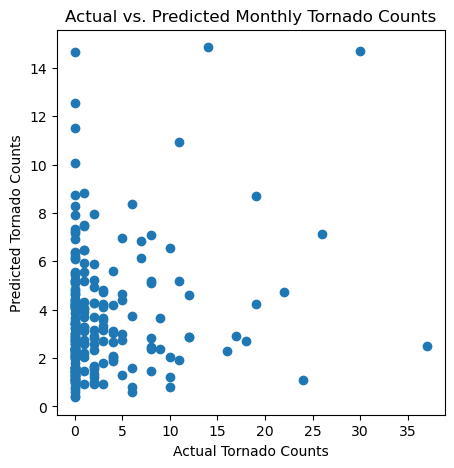

In [16]:
# Set features and target
X = cleaned_df[['ENSO','PDO','NAO','AO']] # Features
y = cleaned_df['il_torn_num'] # Target

# Split test and training data
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.25,
)

# Setup model
model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
)

# Fit model to training data
model.fit(X_train, y_train)

# Predict tornado count on test data
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE
corr = stats.pearsonr(y_pred, y_test) # Corr coeff

print(f'RMSE: {rmse}\nCorrelation Coeff: {corr.statistic}')

# Scatter plot of test vs. predicted data
fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.scatter(y_test, y_pred)
ax.set_xlabel('Actual Tornado Counts')
ax.set_ylabel('Predicted Tornado Counts')
ax.set_title('Actual vs. Predicted Monthly Tornado Counts')

# Part 4: One-hot encoding

In [17]:
# Add month of year column
new_df = cleaned_df.copy()
new_df["month"] = new_df.index.month

# One-hot encode months of year using get_dummies
month_dummies = pd.get_dummies(new_df["month"], prefix="month")

# Add encoded months to original dataframe
new_df = pd.concat([new_df.drop(columns=["month"]), month_dummies], axis=1)
new_df

,ENSO,PDO,NAO,AO,il_torn_num,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
Date,,,,,,,,,,,,,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0.0,True,False,False,False,False,False,False,False,False,False,False,False
1951-02-01,0.9,-1.52,0.70,-0.400,0.0,False,True,False,False,False,False,False,False,False,False,False,False
1951-03-01,-0.1,-1.72,-1.02,-1.934,0.0,False,False,True,False,False,False,False,False,False,False,False,False
1951-04-01,-0.3,-1.35,-0.22,-0.776,0.0,False,False,False,True,False,False,False,False,False,False,False,False
1951-05-01,-0.7,-1.29,-0.59,-0.863,0.0,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-01,0.6,-0.95,-0.28,-0.209,16.0,False,False,False,False,False,False,False,True,False,False,False,False
2021-09-01,0.8,-1.96,-0.21,-0.252,0.0,False,False,False,False,False,False,False,False,True,False,False,False
2021-10-01,0.7,-3.13,-2.29,-0.146,10.0,False,False,False,False,False,False,False,False,False,True,False,False


Fitting 3 folds for each of 216 candidates, totalling 648 fits
RMSE: 7.541681537364111
Correlation Coeff: 0.39138079035275014


Text(0.5, 1.0, 'Actual vs. Predicted Monthly Tornado Counts')

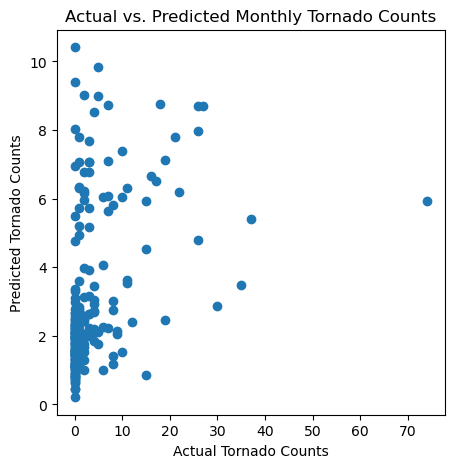

In [27]:
# Rerun model now with encoded months

# Set features and target
X = new_df.drop('il_torn_num', axis=1) # Features
y = new_df['il_torn_num'] # Target

# Split test and training data
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.25,
)

# Set dict with parameters to do grid search on
rf_param_grid = {
    "bootstrap": [True, False],
    "max_depth": [10, 50, 100],
    "max_features": ["sqrt", 1.0, 10],  
    "min_samples_leaf": [1, 4],
    "min_samples_split": [2, 10],
    "n_estimators": [200, 400, 600]}

# Do grid search on RF regressor
rf_grid = GridSearchCV(RandomForestRegressor(), 
                       rf_param_grid, 
                       verbose=1, 
                       cv=3,
                       n_jobs=-1)

rf_grid.fit(X_train, y_train)

'''
# Setup model
model = RandomForestRegressor(
        n_estimators=300,
        max_features=8,
        random_state=None,
        n_jobs=-1
)
'''
model = rf_grid.best_estimator_

# Fit model to training data
model.fit(X_train, y_train)

# Predict tornado count on test data
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE
corr = stats.pearsonr(y_pred, y_test) # Corr coeff

print(f'RMSE: {rmse}\nCorrelation Coeff: {corr.statistic}')

# Scatter plot of test vs. predicted data
fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.scatter(y_test, y_pred)
ax.set_xlabel('Actual Tornado Counts')
ax.set_ylabel('Predicted Tornado Counts')
ax.set_title('Actual vs. Predicted Monthly Tornado Counts')

# Part 5: Feature Importance

In [35]:
# First look at accuracy score of model
print(f"RF train accuracy: {model.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {model.score(X_test, y_test):.3f}")

RF train accuracy: 0.372
RF test accuracy: 0.134


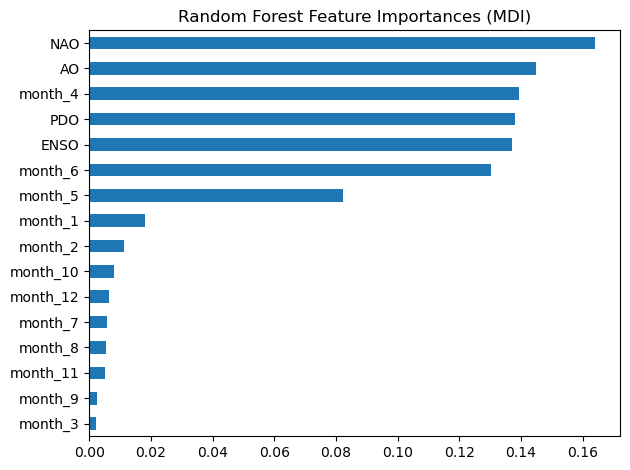

In [29]:
# Feature importance from Mean Decrease in Impurity (MDI)

# Grab feature names
feature_names = X.columns

# Create series of model feature importnances and sort
# from highest to lowest.
mdi_importances = pd.Series(
    model.feature_importances_, index=feature_names
).sort_values(ascending=True)

# Plot bar graph of MDI for each feature
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

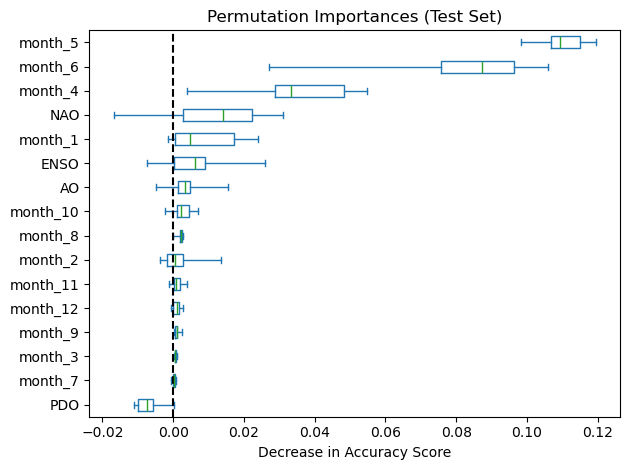

In [30]:
# Perform purmutation analysis

from sklearn.inspection import permutation_importance

# Permutation over test data to see how important each feature
# is to the model's performance. n_repeats is the number of times
# a feature is randomly shuffled and returns a sample of importance.
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Get distribution of importances (decrease in accuracy score) for each
# permutation (shuffling) of each feature. 
sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

# Plot distributions of the accuracy score changes 
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (Test Set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in Accuracy Score")
ax.figure.tight_layout()

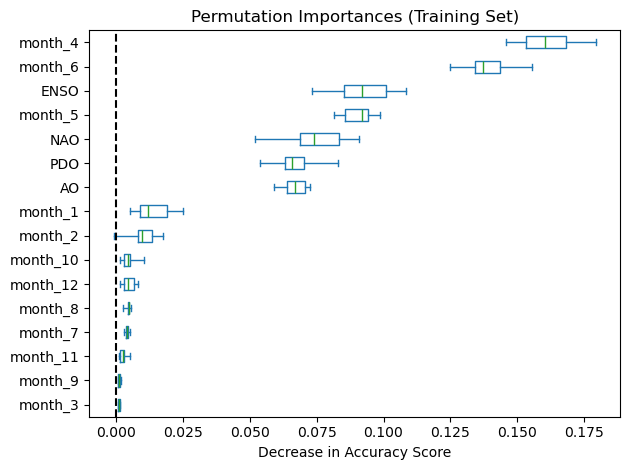

In [31]:
# Now on the training data
result = permutation_importance(
    model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

# Plot distributions of the accuracy score changes 
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (Training Set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in Accuracy Score")
ax.figure.tight_layout()

# Part 6: SHAP Summary Plot

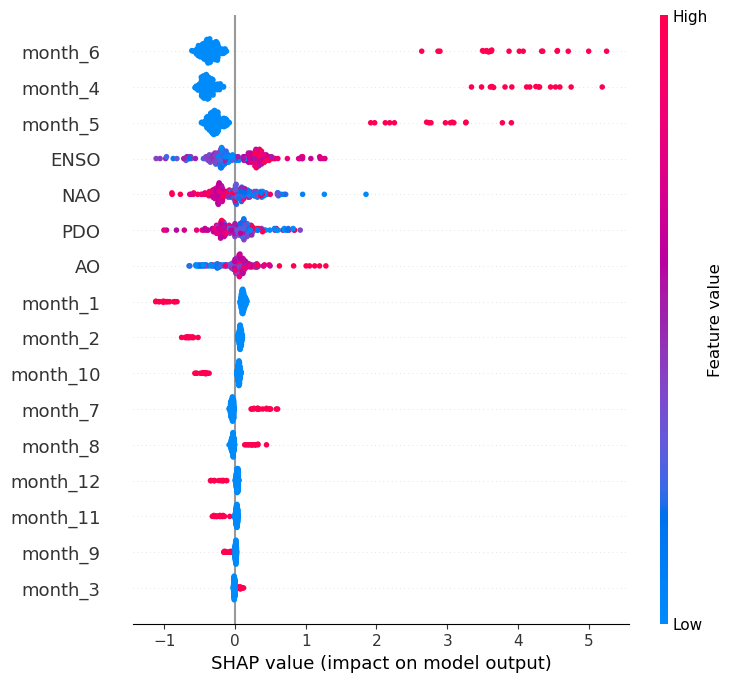

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap

# SHAP explainer RF regression model
explainer = shap.TreeExplainer(model)
# Estimate SHAP values for test features based on rf model
shap_values = explainer(X_test)

# Create summary plot (using beeswarm), each data point in a row is a month.
# X-axis indicates how much each feature increased predicted
# tornado count (more right) or decreased it (more left).
# Color represents whether each index for that data point was high or low.
# Ranking of features defines importance (so month_5 is most important).
plt.figure(figsize=(12, 7))
shap.plots.beeswarm(shap_values, max_display=16)
plt.tight_layout()

# Part 7: ENSO Feature Dependence

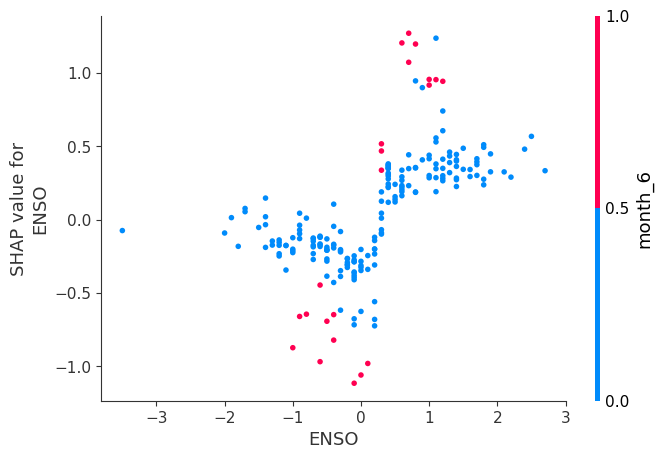

In [33]:
# Plot feature dependence plot for ENSO which shows the feature
# most strongly interacting with the ENSO index, which
# ends up being the month of June. 
shap.dependence_plot("ENSO", shap_values.values, X_test)

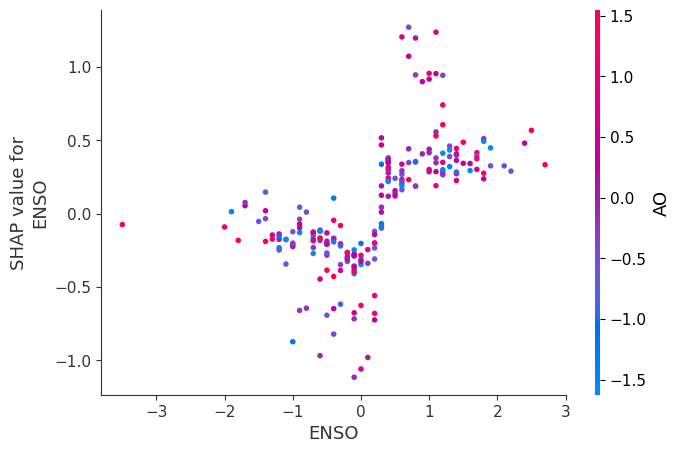

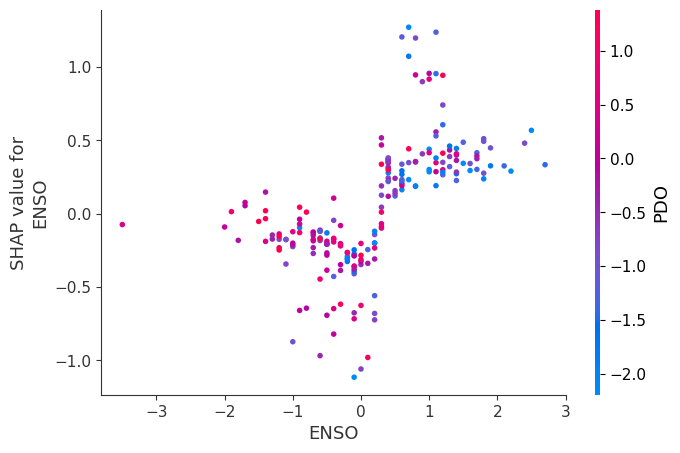

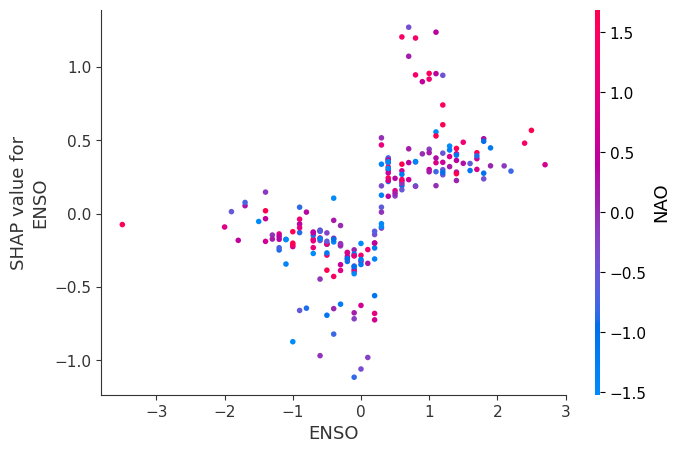

In [34]:
# Also do it for each of the teleconnection indices
tele = ['AO','PDO','NAO']

for t in tele:
    shap.dependence_plot("ENSO", shap_values.values, X_test,
                         interaction_index=t)

# Part 8: Interpretations



The most notable thing I observed from this XAI exercise is the the top 3 most important features were the months of June, April, and May. Judging by the SHAP summary plot,
those features had higher SHIP values (predicted higher tornado counts) when it was those months and negative SHAP values when it wasn't those months, which could be considered a good thing because those are the three most active months for torndoes in Illinois. All 4 teleconnection indices placed below those 3 months in terms of importance ranking, but still showed some interesting patterns in the SHAP summary plot. ENSO clearly showed a dichotomy between positive and negative index values, where positive values (El Nino) generally showed postive SHIP values, while neegative index values (La Nina) showed negative SHIP values. Each one of the teleconnections showed similar dichotomies where the sign of the SHIP values was generally split between whether that climate index was positive or negative. This isn't to say that model performance was good, as we saw that it was not given its low accurracy score, low R^2, and high RMSE, but the model was picking up on patterns from these features that could impact predicted tornado count. In terms of ENSO feature dependence, the month of June showed the strongest interaction with ENSO, interestingly showing some vague clustering of points towards the extrema of the SHAP values for ENSO (see the red dot clusters in the scatter plot). This may suggest that when ENSO is impacting the predicted tornado count the most, it is likely that it is occuring during the month of June. 